<a href="https://colab.research.google.com/github/7235SYXD/Real-Estate/blob/main/DSP_on_Real_Estate_(NB_6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL LIBRARIES                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

import subprocess, sys
for lib in ["kagglehub","catboost","shap","optuna",
            "vaderSentiment","yake","textstat"]:
    subprocess.run([sys.executable,"-m","pip","install",lib,"-q"])
print("All libraries installed.")

All libraries installed.


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GOOGLE DRIVE                                           ║
# ╚══════════════════════════════════════════════════════════════════╝

import os, shutil
from google.colab import drive, files

drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/RealEstate_TXNY"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory: {SAVE_DIR}")

Mounted at /content/drive
Save directory: /content/drive/MyDrive/RealEstate_TXNY


In [3]:
# ╔════════════════════════════════════════════════════╗
# ║  CELL 3 — IMPORT ALL LIBRARIES                     ║
# ╚════════════════════════════════════════════════════╝

import os
import re
import warnings
from pathlib import Path
import gc # Import the garbage collection module

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, f1_score, classification_report,
    accuracy_score,
)

# Gradient boosting
!pip install catboost
from catboost import CatBoostRegressor, CatBoostClassifier
import xgboost as xgb

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hyperparameter tuning
!pip install optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Interpretability
import shap

# NLP
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
!pip install yake
import yake
!pip install textstat
import textstat

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("All libraries imported successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  tensorflow : {tf.__version__}")
print(f"  sklearn    : OK")
print("=" * 60)

All libraries imported successfully.
  pandas     : 2.2.2
  numpy      : 2.0.2
  tensorflow : 2.20.0
  sklearn    : OK


In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  NOTEBOOK 6: SETUP — restores state from Notebook 5              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Loads 336 variables from the dill checkpoint saved by Notebook 5.

Restore mechanism:
    1. pip install dill (fast, already cached)
    2. Open checkpoint_5_to_6.pkl → dill.load() → globals().update()
       Makes all 493 Notebook 5 variables available in this session.
    3. Open checkpoint_5_to_6_keras.json → for each entry,
       keras.models.load_model(path) → globals()[name] = model

"""

import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "dill", "-q"])
import dill, json

CKPT_DIR  = f"{SAVE_DIR}/checkpoints"
CKPT_NAME = "checkpoint_5_to_6"

with open(f"{CKPT_DIR}/{CKPT_NAME}.pkl", "rb") as f:
    _state = dill.load(f)
globals().update(_state)

with open(f"{CKPT_DIR}/{CKPT_NAME}_keras.json") as f:
    _keras_paths = json.load(f)
for _name, _path in _keras_paths.items():
    globals()[_name] = keras.models.load_model(_path)

print("=" * 65)
print(f"CHECKPOINT RESTORED <- {CKPT_DIR}/{CKPT_NAME}.pkl")
print("=" * 65)
print(f"  Variables restored    : {len(_state)}")
print(f"  Keras models restored : {list(_keras_paths.keys()) or 'none'}")
if "df_combined" in globals():
    print(f"  df_combined shape      : {df_combined.shape}")
print(f"\nNotebook 5 state loaded successfully.")
print("Continuing from Cell 30 below, unchanged.")

CHECKPOINT RESTORED <- /content/drive/MyDrive/RealEstate_TXNY/checkpoints/checkpoint_5_to_6.pkl
  Variables restored    : 493
  Keras models restored : ['mlp_base_model', 'mlp_tuned', 'mlp_f', 'mlp_bl_m_obj']
  df_combined shape      : (119979, 51)

Notebook 5 state loaded successfully.
Continuing from Cell 30 below, unchanged.


CELL 30 — CLASSIFICATION: for_sale vs sold (TEST SET)

State values detected in test set: {'UNK': np.int64(8089)}

Classification dataset:
  Train: 65,286  (sold=19,363  for_sale=45,923)
  Test : 8,089

Training RF Classifier ...
Training CatBoost Classifier ...
Training HGB Classifier ...
Training Logistic Regression ...
Training MLP Classifier ...

CLASSIFICATION RESULTS (Test Set):
  Random Forest     AUC=0.7613  Acc=0.6991  F1(sold)=0.5603  F1(macro)=0.6658
  CatBoost          AUC=0.7681  Acc=0.6709  F1(sold)=0.5735  F1(macro)=0.6528
  HGB               AUC=0.7707  Acc=0.6729  F1(sold)=0.5723  F1(macro)=0.6537
  Logistic Reg      AUC=0.5665  Acc=0.5341  F1(sold)=0.4139  F1(macro)=0.5136
  MLP               AUC=0.7119  Acc=0.6588  F1(sold)=0.5198  F1(macro)=0.6276
  Soft Ensemble     AUC=0.7671  Acc=0.6895  F1(sold)=0.5731  F1(macro)=0.6645

Per-State AUC (TX vs NY):
  TX: insufficient samples (0)
  NY: insufficient samples (0)

[Plot 3] No valid TX/NY split found (state column miss

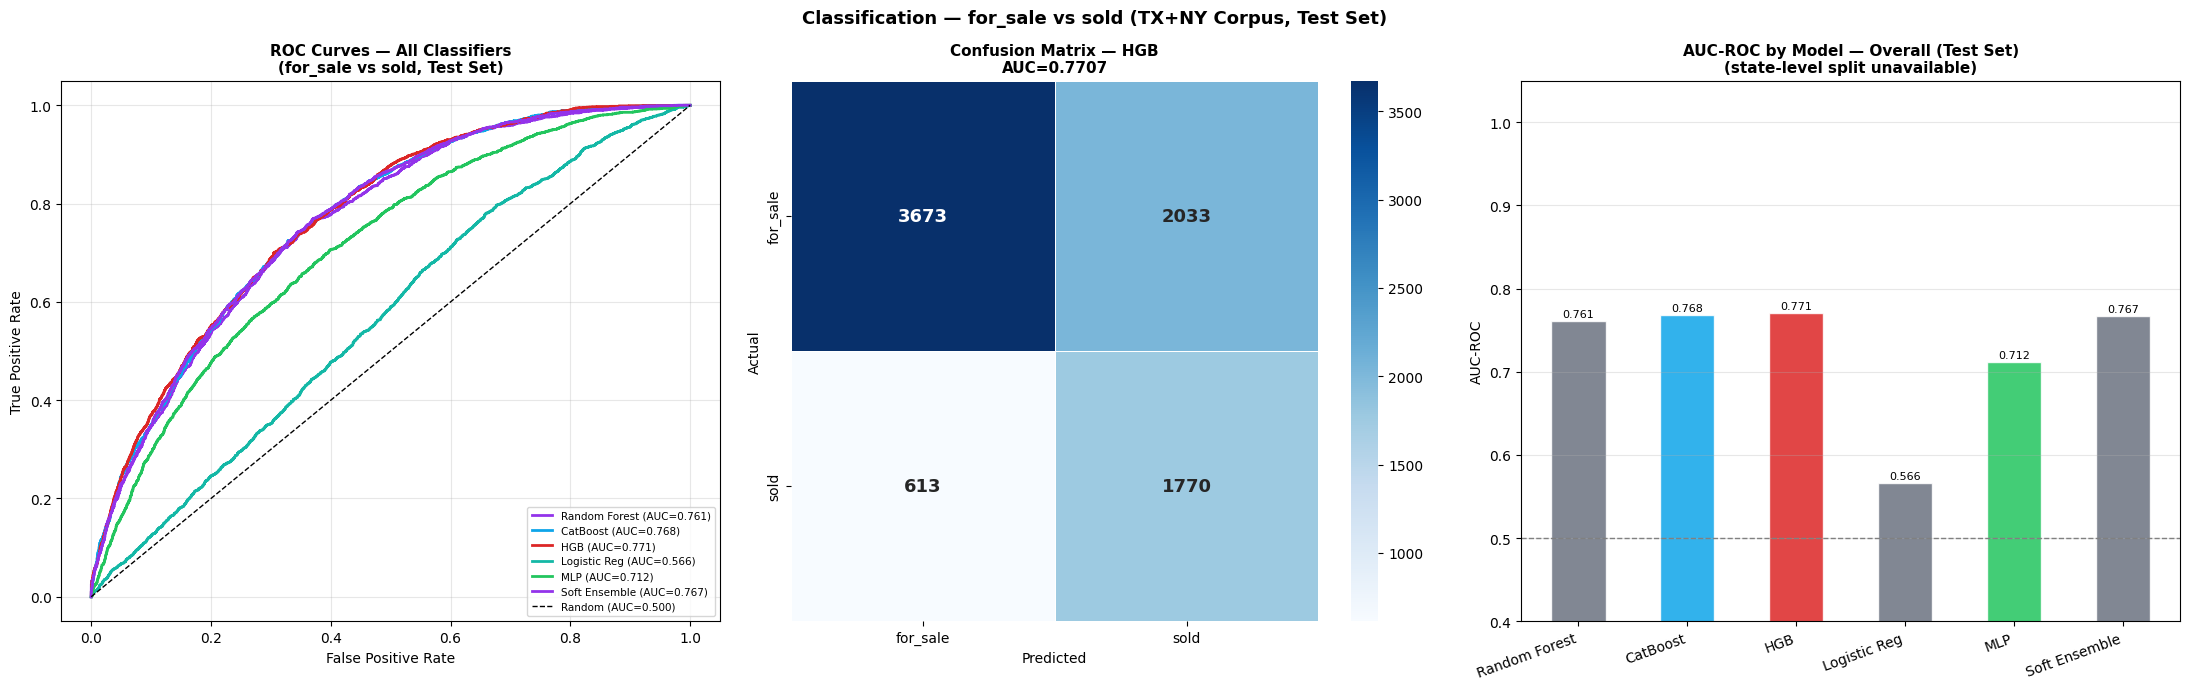


Saved → /content/drive/MyDrive/RealEstate_TXNY/cell30_classification.png

Full Classification Report — HGB:
              precision    recall  f1-score   support

    for_sale       0.86      0.64      0.74      5706
        sold       0.47      0.74      0.57      2383

    accuracy                           0.67      8089
   macro avg       0.66      0.69      0.65      8089
weighted avg       0.74      0.67      0.69      8089



In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 30 — CLASSIFICATION (TX+NY CORPUS — TEST SET)              ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
Binary classification: for_sale (0) vs sold (1).

Models trained: RF Classifier, CatBoost Classifier, Logistic Regression,
                MLP Classifier, HGB Classifier, Soft-Vote Ensemble.

Metrics: AUC-ROC, Accuracy, F1-score, full classification report.
Visualisations:
  Plot 1: AUC-ROC curves for all classifiers
  Plot 2: Confusion matrix (best classifier)
  Plot 3: AUC bar chart per model, split TX vs NY
"""

print("=" * 70)
print("CELL 30 — CLASSIFICATION: for_sale vs sold (TEST SET)")
print("=" * 70)

# ── Check Task B data availability ───────────────────────────────────────────
if y_clf_train is None or y_clf_train.isnull().all():
    print("Task B status column not available — skipping classification.")
    print("Reason: 'status' column was not in SAKIB/POLARTECH after cleaning.")
    print("Action: classification results will be omitted from the summary.")
    DO_CLASSIFICATION = False
else:
    DO_CLASSIFICATION = True

if DO_CLASSIFICATION:
    # ── Prepare clean clf arrays (filter NaN from for_sale/sold)
    clf_idx_tr  = y_clf_train.notna()
    clf_idx_val = y_clf_val.notna()
    clf_idx_tst = y_clf_test.notna()

    y_tr_c  = y_clf_train[clf_idx_tr].astype(int).values
    y_tst_c = y_clf_test[clf_idx_tst].astype(int).values

    Xtr_clf = Xtr_rf[clf_idx_tr.values]
    Xts_clf = Xts_rf[clf_idx_tst.values]
    Xtr_sc_c= Xtr_sc[clf_idx_tr.values]
    Xts_sc_c= Xts_sc[clf_idx_tst.values]
    Xtr_raw_c=Xtr_raw[clf_idx_tr.values]
    Xts_raw_c=Xts_raw[clf_idx_tst.values]

    # ── State split for per-state AUC ────────────────────────────────────────
    def _extract_state(df, mask):
        """Try a few likely column names / casings for the state field."""
        candidates = ["state", "State", "STATE", "state_code", "property_state"]
        for col in candidates:
            if col in df.columns:
                vals = df[col].values[mask.values]
                # normalize: uppercase, strip whitespace, map full names -> abbreviations
                vals = pd.Series(vals).astype(str).str.strip().str.upper()
                vals = vals.replace({"TEXAS": "TX", "NEW YORK": "NY"})
                return vals.values
        return np.array(["UNK"] * mask.sum())

    state_tr  = _extract_state(X_train, clf_idx_tr)
    state_tst = _extract_state(X_test,  clf_idx_tst)

    print(f"\nState values detected in test set: "
          f"{dict(pd.Series(state_tst).value_counts())}")

    from sklearn.utils.class_weight import compute_sample_weight
    sw = compute_sample_weight("balanced", y=y_tr_c)

    print(f"\nClassification dataset:")
    print(f"  Train: {len(y_tr_c):,}  "
          f"(sold={y_tr_c.sum():,}  for_sale={(y_tr_c==0).sum():,})")
    print(f"  Test : {len(y_tst_c):,}")

    # ── Train classifiers ──────────────────────────────────────────────────────
    clf_models = {}

    print("\nTraining RF Classifier ...")
    rfc = RandomForestClassifier(n_estimators=300, max_depth=15,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)
    rfc.fit(Xtr_clf, y_tr_c)
    clf_models["Random Forest"] = rfc

    print("Training CatBoost Classifier ...")
    cbc = CatBoostClassifier(iterations=500, learning_rate=0.05,
                              depth=6, random_seed=SEED, verbose=0,
                              auto_class_weights="Balanced")
    cbc.fit(Xtr_clf, y_tr_c)
    clf_models["CatBoost"] = cbc

    print("Training HGB Classifier ...")
    hgbc = HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=500,
        max_depth=6, random_state=SEED,
        class_weight="balanced")
    hgbc.fit(Xtr_raw_c, y_tr_c)
    clf_models["HGB"] = hgbc

    print("Training Logistic Regression ...")
    lr_clf = LogisticRegression(C=0.1, max_iter=500,
                                 class_weight="balanced", random_state=SEED)
    lr_clf.fit(Xtr_sc_c, y_tr_c)
    clf_models["Logistic Reg"] = lr_clf

    print("Training MLP Classifier ...")
    mlp_clf = keras.Sequential([
        layers.Input(shape=(n_feat,)),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    mlp_clf.compile(optimizer=keras.optimizers.Adam(0.001),
                     loss="binary_crossentropy")
    mlp_clf.fit(Xtr_sc_c, y_tr_c, epochs=50, batch_size=512, verbose=0,
                 sample_weight=sw,
                 callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)])
    clf_models["MLP"] = mlp_clf

    # ── Collect test probabilities ──────────────────────────────────────────────
    proba_dict = {
        "Random Forest": rfc.predict_proba(Xts_clf)[:, 1],
        "CatBoost":      cbc.predict_proba(Xts_clf)[:, 1],
        "HGB":           hgbc.predict_proba(Xts_raw_c)[:, 1],
        "Logistic Reg":  lr_clf.predict_proba(Xts_sc_c)[:, 1],
        "MLP":           mlp_clf.predict(Xts_sc_c, verbose=0).flatten(),
    }
    # Soft-vote ensemble
    proba_dict["Soft Ensemble"] = np.mean(list(proba_dict.values()), axis=0)

    # ── Metrics table ───────────────────────────────────────────────────────────
    print("\nCLASSIFICATION RESULTS (Test Set):")
    clf_rows = []
    for mname, prob in proba_dict.items():
        pred    = (prob >= 0.5).astype(int)
        auc     = roc_auc_score(y_tst_c, prob)
        acc     = accuracy_score(y_tst_c, pred)
        f1      = f1_score(y_tst_c, pred, zero_division=0)
        f1_macro= f1_score(y_tst_c, pred, average="macro", zero_division=0)
        clf_rows.append({"Model": mname, "AUC-ROC": auc,
                          "Accuracy": acc, "F1 (sold)": f1, "F1 (macro)": f1_macro})
        print(f"  {mname:16s}  AUC={auc:.4f}  Acc={acc:.4f}  "
              f"F1(sold)={f1:.4f}  F1(macro)={f1_macro:.4f}")

    clf_df = pd.DataFrame(clf_rows)

    # Per-state AUC (console)
    print("\nPer-State AUC (TX vs NY):")
    for state_code in ["TX", "NY"]:
        mask = state_tst == state_code
        if mask.sum() < 20:
            print(f"  {state_code}: insufficient samples ({mask.sum()})")
            continue
        for mname, prob in proba_dict.items():
            try:
                auc_s = roc_auc_score(y_tst_c[mask], prob[mask])
                print(f"  {state_code}  {mname:16s}: AUC={auc_s:.4f}")
            except Exception:
                pass

    # ── Plots ───────────────────────────────────────────────────────────────────
    fig30, axes30 = plt.subplots(1, 3, figsize=(22, 7))

    # Plot 1: AUC-ROC curves
    from sklearn.metrics import roc_curve
    ax_roc = axes30[0]
    colors_clf = [PAL["RF"], PAL["CatBoost"], PAL["HGB"],
                  "#14B8A6", PAL["MLP"], PAL["Stack"]]
    for (mname, prob), col in zip(proba_dict.items(), colors_clf):
        fpr, tpr, _ = roc_curve(y_tst_c, prob)
        auc_v = roc_auc_score(y_tst_c, prob)
        ax_roc.plot(fpr, tpr, linewidth=2, color=col,
                     label=f"{mname} (AUC={auc_v:.3f})")
    ax_roc.plot([0,1],[0,1], "k--", linewidth=1, label="Random (AUC=0.500)")
    ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("ROC Curves — All Classifiers\n(for_sale vs sold, Test Set)",
                      fontweight="bold", fontsize=11)
    ax_roc.legend(fontsize=7.5, loc="lower right"); ax_roc.grid(alpha=0.3)

    # Plot 2: Confusion matrix — best classifier
    best_clf_name = clf_df.loc[clf_df["AUC-ROC"].idxmax(), "Model"]
    best_prob     = proba_dict[best_clf_name]
    best_pred_clf = (best_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_tst_c, best_pred_clf)
    ax_cm = axes30[1]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                 xticklabels=["for_sale","sold"],
                 yticklabels=["for_sale","sold"],
                 ax=ax_cm, linewidths=0.5,
                 annot_kws={"size": 13, "weight": "bold"})
    ax_cm.set_xlabel("Predicted"); ax_cm.set_ylabel("Actual")
    ax_cm.set_title(f"Confusion Matrix — {best_clf_name}\n"
                     f"AUC={clf_df.loc[clf_df['AUC-ROC'].idxmax(),'AUC-ROC']:.4f}",
                     fontweight="bold", fontsize=11)

    # Plot 3: AUC bar per model split by state
    ax_state = axes30[2]
    state_auc_rows = []
    for state_code, col_s in [("TX", PAL["TX"]), ("NY", PAL["NY"])]:
        mask_s = state_tst == state_code
        if mask_s.sum() < 20:
            continue
        for mname, prob in proba_dict.items():
            try:
                auc_s = roc_auc_score(y_tst_c[mask_s], prob[mask_s])
                state_auc_rows.append({"Model": mname, "State": state_code, "AUC": auc_s})
            except Exception:
                pass

    if state_auc_rows:
        # ---- normal path: real TX vs NY split found ----
        sa_df = pd.DataFrame(state_auc_rows)
        states_present = sa_df["State"].unique()
        models_order = sa_df["Model"].unique()
        x_cls  = np.arange(len(models_order))
        w_sa   = 0.35
        for si, (sc_s, col_s) in enumerate([("TX", PAL["TX"]), ("NY", PAL["NY"])]):
            if sc_s not in states_present:
                continue
            vals = [sa_df[(sa_df["Model"]==m) & (sa_df["State"]==sc_s)]["AUC"].values
                    for m in models_order]
            vals = [v[0] if len(v) else 0 for v in vals]
            offset = -w_sa/2 + si*w_sa
            bars_sa = ax_state.bar(x_cls + offset, vals, w_sa,
                                    label=sc_s, color=col_s, alpha=0.85, edgecolor="white")
            for bar, v in zip(bars_sa, vals):
                if v > 0:
                    ax_state.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                                   f"{v:.3f}", ha="center", fontsize=7)
        ax_state.set_xticks(x_cls)
        ax_state.set_xticklabels(models_order, rotation=20, ha="right")
        ax_state.set_ylim(0.4, 1.05); ax_state.set_ylabel("AUC-ROC")
        ax_state.set_title("AUC-ROC by State — TX vs NY\n(Classification Task)",
                             fontweight="bold", fontsize=11)
        ax_state.legend(fontsize=9); ax_state.grid(axis="y", alpha=0.3)
        ax_state.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    else:
        # ---- fallback path: no usable state split — show overall AUC per model instead ----
        print("\n[Plot 3] No valid TX/NY split found (state column missing, "
              "unrecognized values, or <20 samples per state) — "
              "falling back to an overall AUC-ROC bar chart per model.")
        overall_models = list(clf_df["Model"])
        overall_aucs   = list(clf_df["AUC-ROC"])
        x_cls = np.arange(len(overall_models))
        bars_sa = ax_state.bar(x_cls, overall_aucs, 0.5,
                                color=[PAL.get(m, "#6B7280") for m in overall_models],
                                alpha=0.85, edgecolor="white")
        for bar, v in zip(bars_sa, overall_aucs):
            ax_state.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                           f"{v:.3f}", ha="center", fontsize=8)
        ax_state.set_xticks(x_cls)
        ax_state.set_xticklabels(overall_models, rotation=20, ha="right")
        ax_state.set_ylim(0.4, 1.05); ax_state.set_ylabel("AUC-ROC")
        ax_state.set_title("AUC-ROC by Model — Overall (Test Set)\n"
                            "(state-level split unavailable)",
                             fontweight="bold", fontsize=11)
        ax_state.grid(axis="y", alpha=0.3)
        ax_state.axhline(0.5, color="gray", linestyle="--", linewidth=1)

    plt.suptitle("Classification — for_sale vs sold (TX+NY Corpus, Test Set)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/cell30_classification.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\nSaved → {SAVE_DIR}/cell30_classification.png")

    # Best model classification report
    print(f"\nFull Classification Report — {best_clf_name}:")
    print(classification_report(y_tst_c, best_pred_clf,
                                  target_names=["for_sale","sold"]))

CELL 31 — 3-WAY ABLATION STUDY

Feature counts per config:
  Config A (Structural only)     : 6 features
  Config B (+ Location)          : 14 features
  Config C (+ Location + NLP)    : 28 features

Training CatBoost for each ablation config ...
  A — Structural only: R²=0.3418  RMSE=0.7358  Real-MAE=$176,011  features=6
  B — Structural + Location: R²=0.7768  RMSE=0.4285  Real-MAE=$67,474  features=14
  C — Structural + Location + NLP: R²=0.7781  RMSE=0.4272  Real-MAE=$67,317  features=28

  Location lift (B−A) : ΔRMSE = +0.3073  ΔR² = +0.4350
  NLP lift       (C−B): ΔRMSE = +0.0013  ΔR² = +0.0013
  Total lift     (C−A): ΔRMSE = +0.3086  ΔR² = +0.4363


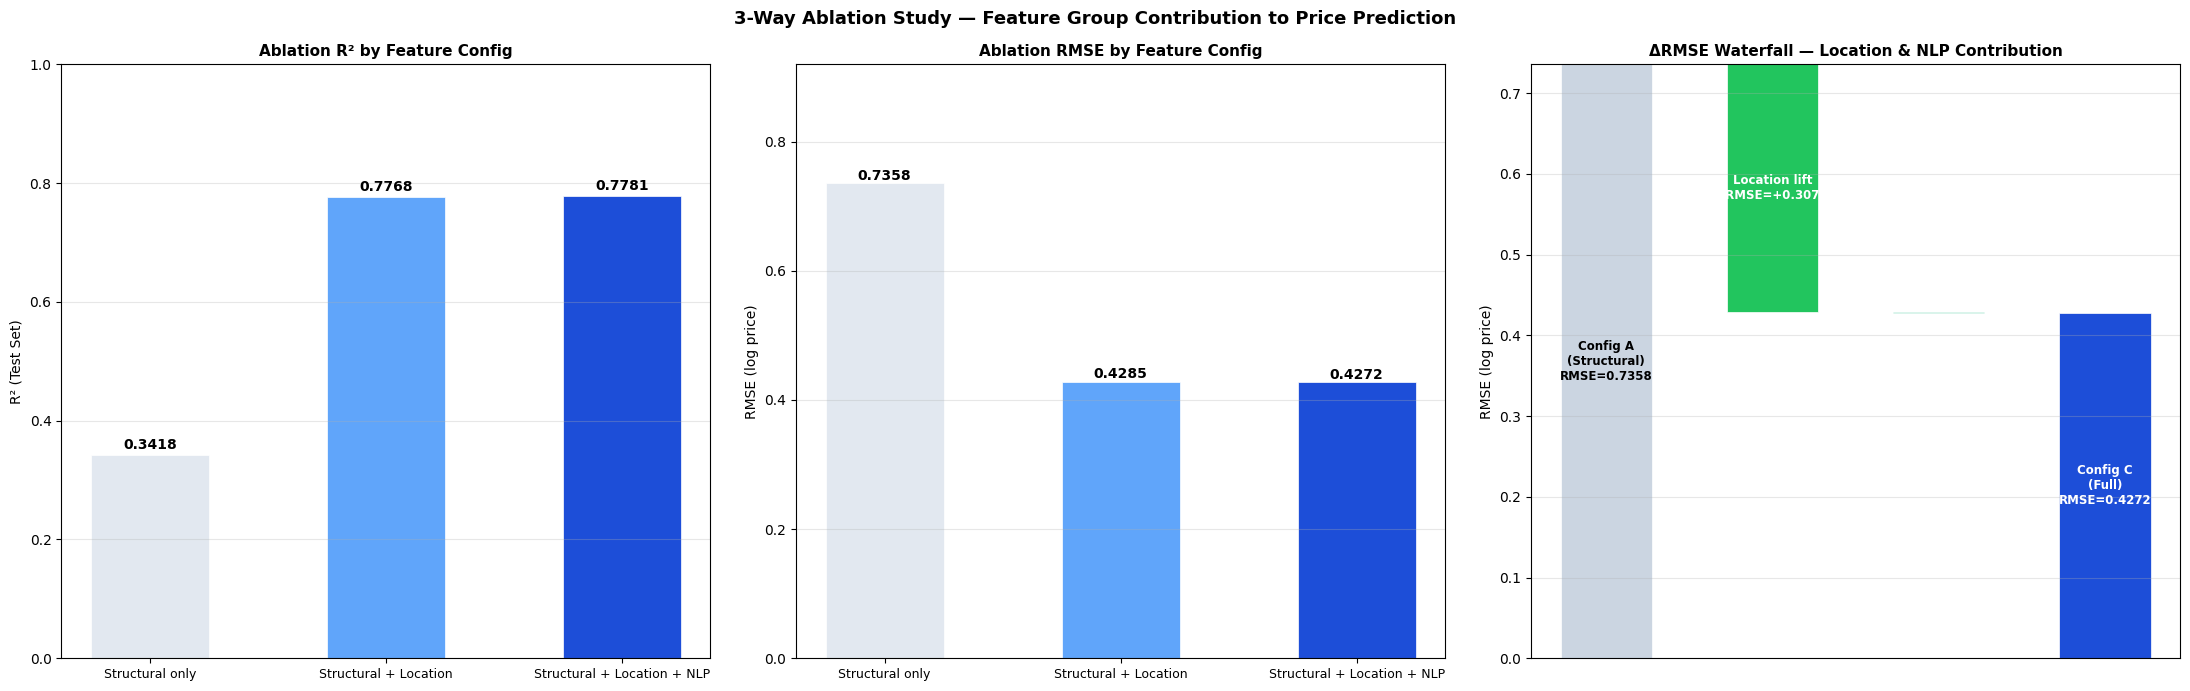


Saved → /content/drive/MyDrive/RealEstate_TXNY/cell31_ablation.png


In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 31 — 3-WAY ABLATION STUDY WITH VISUALISATION               ║
# ╚══════════════════════════════════════════════════════════════════╝
"""
3-way ablation study answers the research question:
  "How much does each feature group contribute to prediction accuracy?"

Three configurations:
  Config A — Structural only
    Features: bed, bath, sqft, acre_lot, log_house_size, bed_bath_ratio
    Purpose : baseline without any location or NLP signal
    Expected: lowest R² (~0.30–0.45)

  Config B — Structural + Location
    Adds    : is_tx/ny, zip_numeric, zip_median_price, city_median_price,
              latitude, longitude, price_per_sqft
    Purpose : quantify how much ZIP/city location encoding adds
    Expected: large jump to ~0.65–0.75 (location dominates price)

  Config C — Structural + Location + NLP (full model)
    Adds    : all 14 nlp_* columns
    Purpose : quantify description NLP contribution over Config B
    Expected: small but positive ΔRMSE (NLP is state-level, low variance)

The ΔRMSE between configs is the ablation signal:
  Location lift = RMSE(A) − RMSE(B)
  NLP lift      = RMSE(B) − RMSE(C)

All ablation models use CatBoost with the SAME tuned hyperparameters
for a fair comparison.
"""

print("=" * 70)
print("CELL 31 — 3-WAY ABLATION STUDY")
print("=" * 70)

# ── Define feature groups ──────────────────────────────────────────────────────
structural_feats = [c for c in final_features
                    if c in [bed_col, bath_col, sqft_col, "acre_lot",
                              "log_house_size", "bed_bath_ratio"]
                    and c is not None]
location_feats   = [c for c in final_features
                    if c in ["is_tx_listing","is_ny_listing","zip_numeric",
                              "zip_median_price","city_median_price",
                              "latitude","longitude","price_per_sqft"]]
nlp_feats        = [c for c in final_features if c.startswith("nlp_")]

config_A = structural_feats
config_B = structural_feats + location_feats
config_C = structural_feats + location_feats + nlp_feats

print(f"\nFeature counts per config:")
print(f"  Config A (Structural only)     : {len(config_A)} features")
print(f"  Config B (+ Location)          : {len(config_B)} features")
print(f"  Config C (+ Location + NLP)    : {len(config_C)} features")

# ── Train and evaluate each config ────────────────────────────────────────────
abl_results = {}
print("\nTraining CatBoost for each ablation config ...")
for cfg_name, cfg_feats in [("A — Structural only",          config_A),
                              ("B — Structural + Location",     config_B),
                              ("C — Structural + Location + NLP", config_C)]:
    avail = [c for c in cfg_feats if c in X_train.columns]
    if len(avail) == 0:
        print(f"  {cfg_name}: no features available — skipped")
        continue
    imp_abl = SimpleImputer(strategy="median")
    Xtr_abl = imp_abl.fit_transform(X_train[avail].values)
    Xts_abl = imp_abl.transform(X_test[avail].values)
    m = CatBoostRegressor(
        iterations    = cb_bp.get("iters", 500),
        learning_rate = cb_bp.get("lr", 0.05),
        depth         = cb_bp.get("depth", 6),
        l2_leaf_reg   = cb_bp.get("l2", 3.0),
        subsample     = cb_bp.get("sub", 0.8),
        random_seed=SEED, verbose=0)
    m.fit(Xtr_abl, y_reg_train)
    pred = m.predict(Xts_abl)
    rmse = np.sqrt(mean_squared_error(y_ts, pred))
    r2   = r2_score(y_ts, pred)
    mae  = mean_absolute_error(np.expm1(y_ts), np.expm1(pred))
    abl_results[cfg_name] = {"R²": r2, "RMSE": rmse,
                               "Real_MAE_$": mae, "n_feats": len(avail)}
    print(f"  {cfg_name}: R²={r2:.4f}  RMSE={rmse:.4f}  "
          f"Real-MAE=${mae:,.0f}  features={len(avail)}")

# ── Deltas ────────────────────────────────────────────────────────────────────
keys = list(abl_results.keys())
if len(keys) >= 2:
    dA   = abl_results[keys[0]]["RMSE"]
    dB   = abl_results[keys[1]]["RMSE"] if len(keys)>1 else dA
    dC   = abl_results[keys[2]]["RMSE"] if len(keys)>2 else dB
    loc_lift  = dA - dB
    nlp_lift  = dB - dC
    tot_lift  = dA - dC
    r2_A, r2_B = abl_results[keys[0]]["R²"], abl_results[keys[1]]["R²"]
    r2_C = abl_results[keys[2]]["R²"] if len(keys)>2 else r2_B
    print(f"\n  Location lift (B−A) : ΔRMSE = {loc_lift:+.4f}  "
          f"ΔR² = {r2_B-r2_A:+.4f}")
    print(f"  NLP lift       (C−B): ΔRMSE = {nlp_lift:+.4f}  "
          f"ΔR² = {r2_C-r2_B:+.4f}")
    print(f"  Total lift     (C−A): ΔRMSE = {tot_lift:+.4f}  "
          f"ΔR² = {r2_C-r2_A:+.4f}")

# ── Visualisations ─────────────────────────────────────────────────────────────
fig31, axes31 = plt.subplots(1, 3, figsize=(22, 7))
cfg_labels    = [k.split("—")[1].strip() for k in abl_results.keys()]
cfg_r2_vals   = [v["R²"]   for v in abl_results.values()]
cfg_rmse_vals = [v["RMSE"] for v in abl_results.values()]
cfg_colors    = ["#E2E8F0","#60A5FA","#1D4ED8"][:len(cfg_labels)]

# Plot 1: R² by config
ax_abl1 = axes31[0]
bars_abl = ax_abl1.bar(cfg_labels, cfg_r2_vals, color=cfg_colors,
                         edgecolor="white", linewidth=0.5, width=0.5)
ax_abl1.set_ylim(0, 1); ax_abl1.set_ylabel("R² (Test Set)")
ax_abl1.set_title("Ablation R² by Feature Config", fontweight="bold", fontsize=11)
ax_abl1.grid(axis="y", alpha=0.3)
for bar, v in zip(bars_abl, cfg_r2_vals):
    ax_abl1.text(bar.get_x()+bar.get_width()/2, v+0.01,
                  f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
ax_abl1.tick_params(axis="x", labelsize=9)

# Plot 2: RMSE by config
ax_abl2 = axes31[1]
bars_rm = ax_abl2.bar(cfg_labels, cfg_rmse_vals, color=cfg_colors,
                        edgecolor="white", linewidth=0.5, width=0.5)
ax_abl2.set_ylabel("RMSE (log price)"); ax_abl2.set_ylim(0, max(cfg_rmse_vals)*1.25)
ax_abl2.set_title("Ablation RMSE by Feature Config", fontweight="bold", fontsize=11)
ax_abl2.grid(axis="y", alpha=0.3)
for bar, v in zip(bars_rm, cfg_rmse_vals):
    ax_abl2.text(bar.get_x()+bar.get_width()/2, v+0.005,
                  f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
ax_abl2.tick_params(axis="x", labelsize=9)

# Plot 3: Waterfall of ΔRMSE lifts
ax_abl3 = axes31[2]
if len(keys) >= 3:
    lift_labels = [f"Config A\n(Structural)\nRMSE={dA:.4f}",
                   f"Location lift\nΔRMSE={loc_lift:+.4f}",
                   f"NLP lift\nΔRMSE={nlp_lift:+.4f}",
                   f"Config C\n(Full)\nRMSE={dC:.4f}"]
    starts  = [0, dA, dB, 0]
    heights = [dA, -loc_lift, -nlp_lift, dC]
    bar_cols = ["#CBD5E1","#22C55E","#10B981","#1D4ED8"]
    for i, (lbl, s, h, col) in enumerate(zip(lift_labels, starts, heights, bar_cols)):
        ax_abl3.bar(i, h, bottom=s if i in (1,2) else 0,
                     color=col, edgecolor="white", linewidth=0.5, width=0.55)
        ax_abl3.text(i, (s + h/2) if i in (1,2) else h/2,
                      lbl, ha="center", va="center", fontsize=8.5, fontweight="bold",
                      color="white" if i > 0 else "black")
    ax_abl3.set_xticks([])
    ax_abl3.set_ylabel("RMSE (log price)")
    ax_abl3.set_title("ΔRMSE Waterfall — Location & NLP Contribution",
                       fontweight="bold", fontsize=11)
    ax_abl3.grid(axis="y", alpha=0.3)

plt.suptitle("3-Way Ablation Study — Feature Group Contribution to Price Prediction",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/cell31_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved → {SAVE_DIR}/cell31_ablation.png")